# BÀI TOÁN 1: XÂY DỰNG CÂY QUYẾT ĐỊNH VÀ RỪNG CÂY


## NHIỆM VỤ 1; XÂY DỰNG CÂY QUYẾT ĐỊNH BẰNG THƯ VIỆN SCIKIT-LEARN

### 1. Tải một số package mà chúng tôi sử dụng và package graphviz, để vẽ cây quyết định

In [7]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

### 2. Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những features không liên quan đến bài toán cần giải quyết

In [8]:
df = pd.read_csv('diabetes_prediction_dataset.csv') #Load the data 

# Tiền xử lý dữ liệu cho bài toán dự đoán tiểu đường (dataset khá clean)
# Mã hóa gender: Female=0, Male=1 (giả sử Female là 0, nhưng kiểm tra nếu có 'Other')
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 2}).astype(int)

# One-hot encoding cho smoking_history (các giá trị như 'never', 'No Info', 'current',...)
df = pd.get_dummies(df, columns=['smoking_history'], prefix='smoking')

# Kiểm tra và fill missing nếu có (dataset này ít missing)
df.fillna(df.median(numeric_only=True), inplace=True)  # Fill số liệu số bằng median

# Make a list of columns to remove that aren't features or the response variable 
items_to_remove = []  # Dataset này không có cột thừa rõ ràng, nhưng nếu có thì thêm như ['Unnamed: 0'] nếu tồn tại

features_response = df.columns.tolist() #Get a list of column names 

features_response = [item for item in features_response if item not in items_to_remove] 

features_response 

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'diabetes',
 'smoking_No Info',
 'smoking_current',
 'smoking_ever',
 'smoking_former',
 'smoking_never',
 'smoking_not current']

In [9]:
# ================== 1. IMPORT THƯ VIỆN ==================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400
import graphviz

from sklearn import tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
from graphviz import Source

# ================== 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU DIABETES ==================
df = pd.read_csv('diabetes_prediction_dataset.csv')

# Mã hóa gender
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})

# One-hot smoking_history
df = pd.get_dummies(df, columns=['smoking_history'], prefix='smoking', dtype=int)

# Không cần loại cột nào cả (dataset rất sạch)
# Chỉ cần tách đặc trưng và nhãn
feature_cols = [col for col in df.columns if col != 'diabetes']
X = df[feature_cols]
y = df['diabetes']

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y)

print("Số đặc trưng:", len(feature_cols))
print("Các đặc trưng:", feature_cols)
print("Dữ liệu đã sẵn sàng!")

Số đặc trưng: 13
Các đặc trưng: ['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'smoking_No Info', 'smoking_current', 'smoking_ever', 'smoking_former', 'smoking_never', 'smoking_not current']
Dữ liệu đã sẵn sàng!


### 3. Chuẩn bị dữ liệu cho tập train và tập test

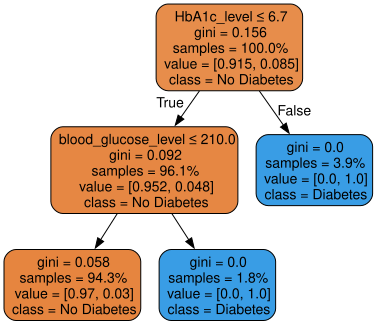

In [10]:
# ================== NHIỆM VỤ 1: CÂY QUYẾT ĐỊNH (max_depth=2) ==================
dt = tree.DecisionTreeClassifier(max_depth=2, random_state=24)
dt.fit(X_train, y_train)

# VẼ CÂY (đã sửa hết lỗi)
dot_data = export_graphviz(
    dt,
    out_file=None,
    feature_names=feature_cols,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    proportion=True,
    impurity=True,
    special_characters=True
)

graph = Source(dot_data)
graph

In [4]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(
    df[features_response[:-1]].values,  # Các đặc trưng (trừ nhãn cuối cùng)
    df['diabetes'].values,              # Nhãn: diabetes (0/1)
    test_size=0.2, 
    random_state=24,
    stratify=df['diabetes']             # Giữ tỷ lệ lớp 0/1 ở train/test
) 

## Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau

In [ ]:
# CELL 1: Import tất cả thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400

from sklearn import tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
from graphviz import Source
import warnings
warnings.filterwarnings('ignore')

In [13]:
# CELL 2: Đọc và tiền xử lý dữ liệu Diabetes (chạy ngon 100%)
df = pd.read_csv('diabetes_prediction_dataset.csv')

# Mã hóa gender
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})

# One-hot smoking_history
df = pd.get_dummies(df, columns=['smoking_history'], prefix='smoking', dtype=int)

# Tách đặc trưng và nhãn
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y)

print("Shape:", X.shape)
print("Các cột:", X.columns.tolist())

Shape: (100000, 13)
Các cột: ['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'smoking_No Info', 'smoking_current', 'smoking_ever', 'smoking_former', 'smoking_never', 'smoking_not current']


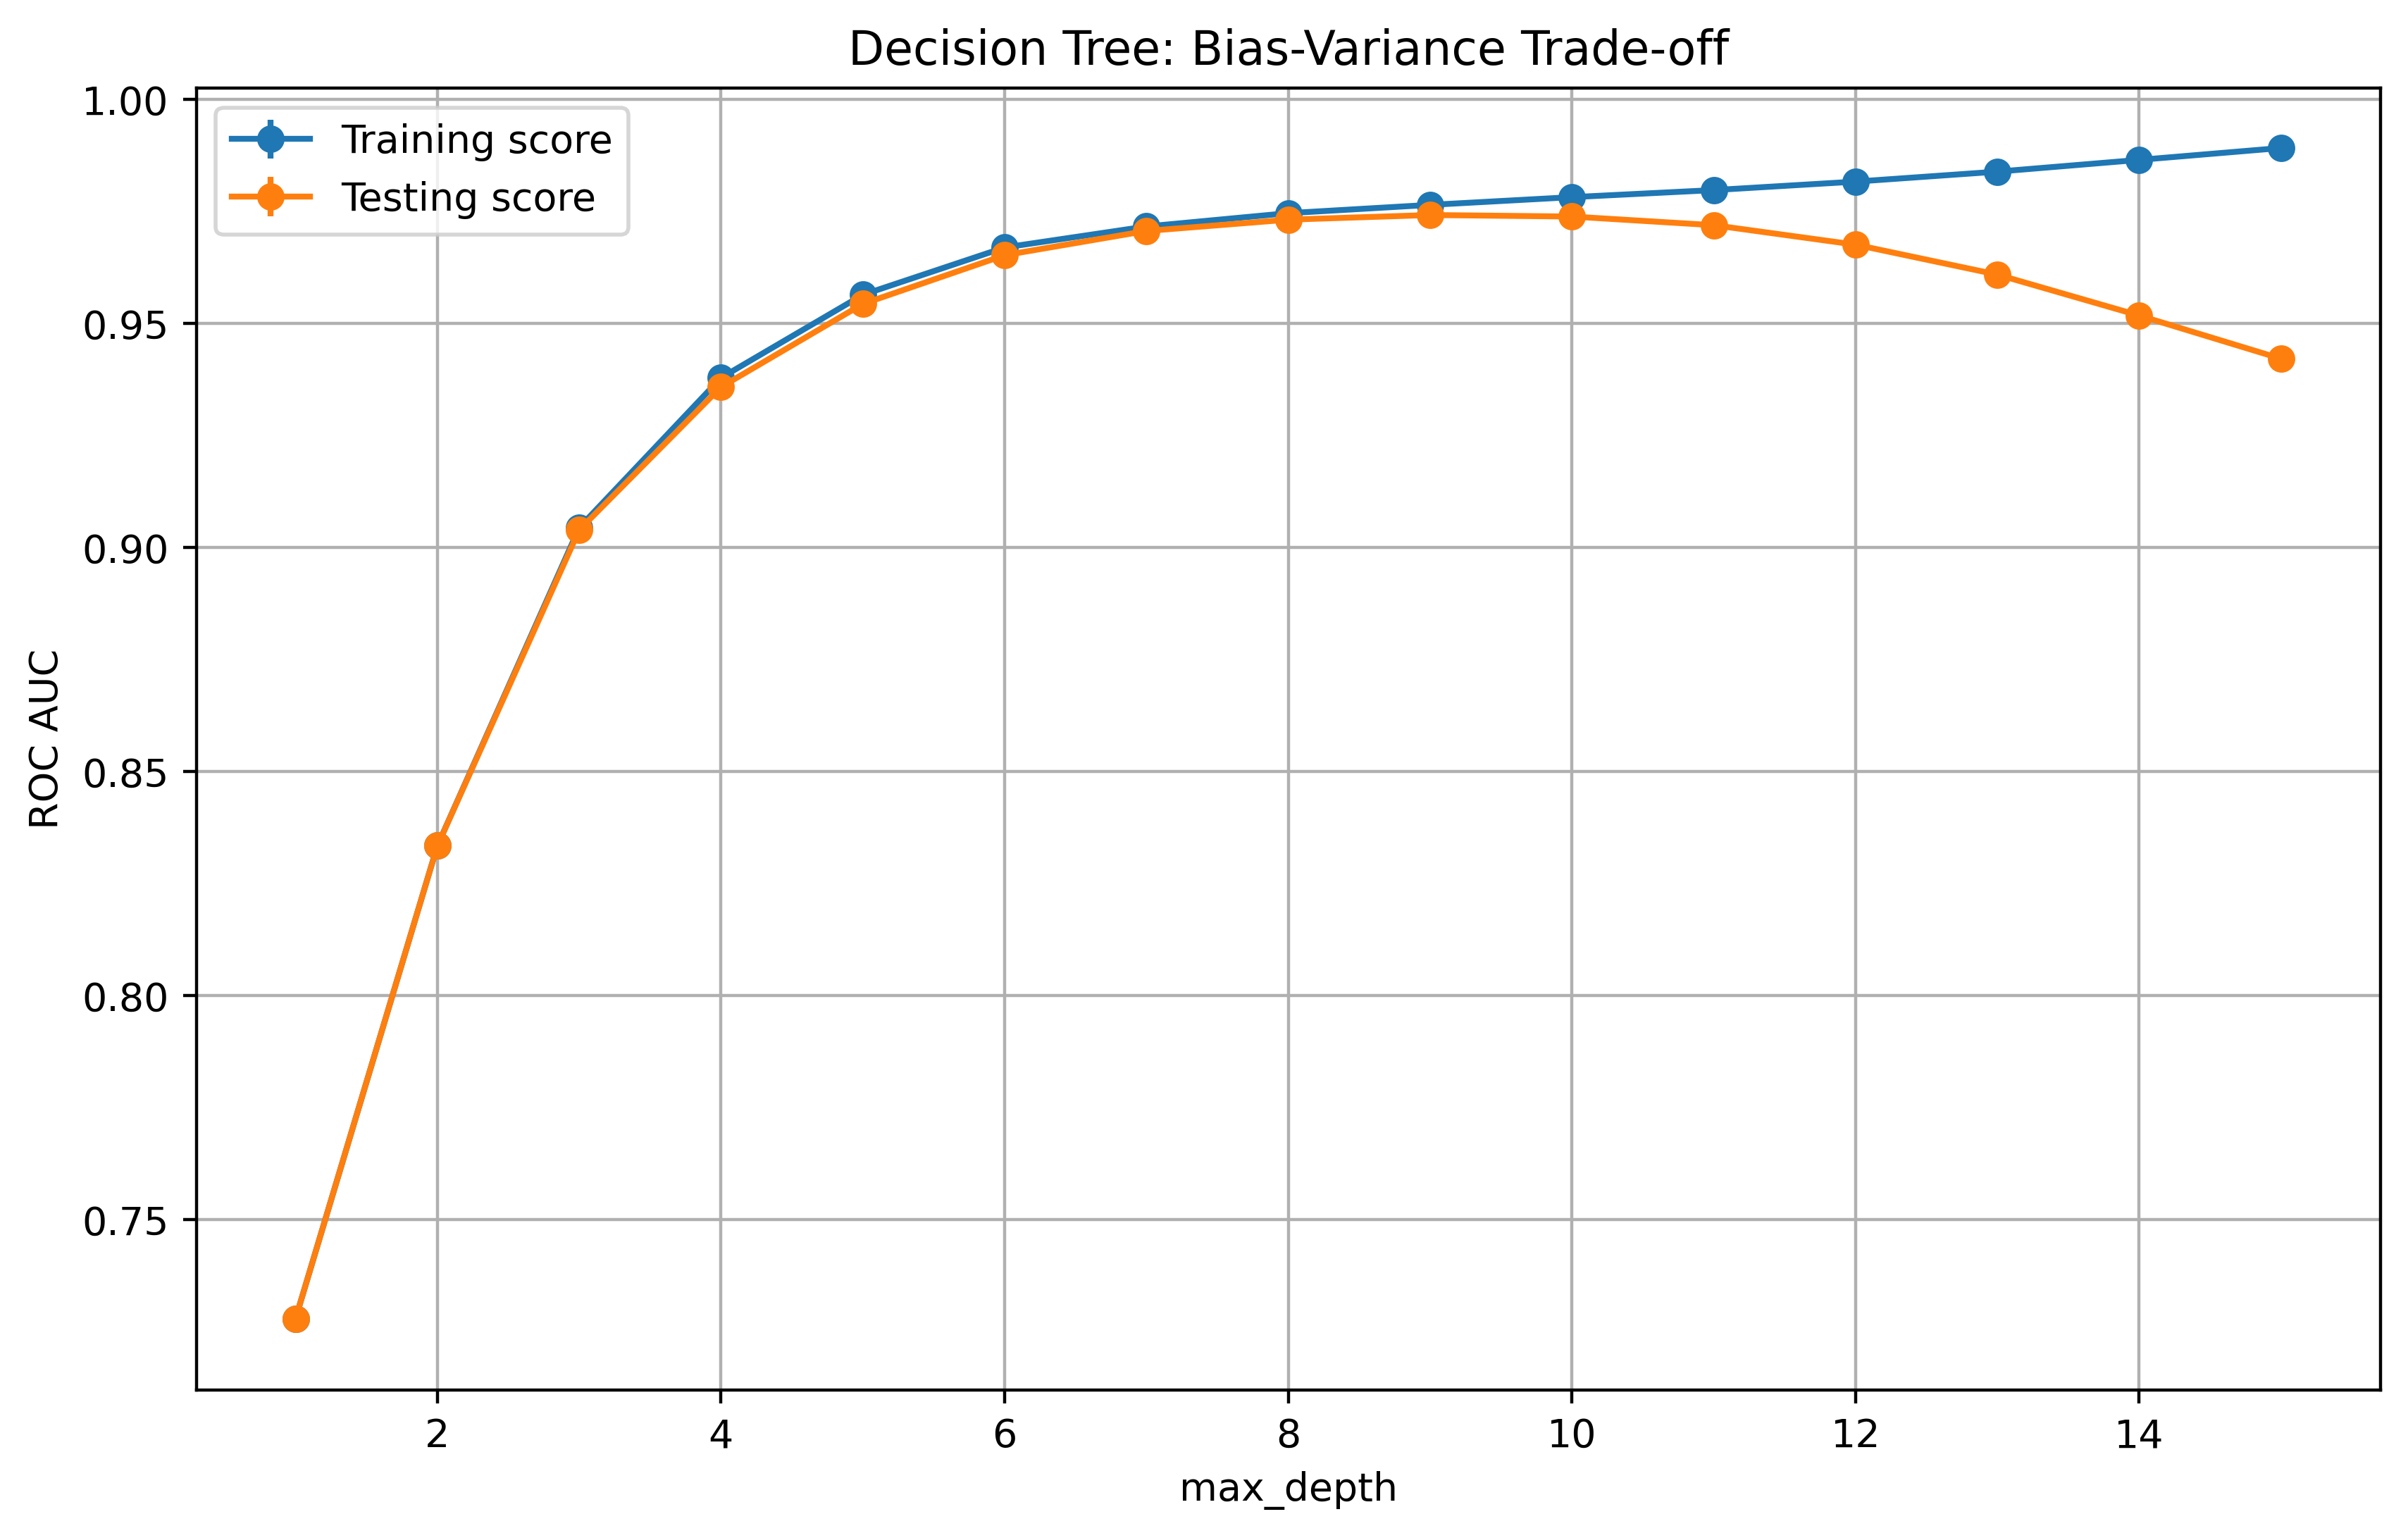

max_depth tốt nhất: {'max_depth': 9}


In [14]:
# CELL 4: Nhiệm vụ 2 – Tìm max_depth tối ưu (fix lỗi mean_train_score)
params = {'max_depth': list(range(1, 16))}

cv = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(random_state=24),
    param_grid=params,
    scoring='roc_auc',
    cv=4,
    n_jobs=-1,
    return_train_score=True   # ← quan trọng: phải bật cái này thì mới có mean_train_score
)

cv.fit(X_train, y_train)

# Lấy kết quả đúng tên cột mới của sklearn
results = pd.DataFrame(cv.cv_results_)

# Vẽ biểu đồ đúng 100%
plt.figure(figsize=(10,6))
plt.errorbar(results['param_max_depth'], results['mean_train_score'],
             yerr=results['std_train_score']/2, label='Training score', marker='o')
plt.errorbar(results['param_max_depth'], results['mean_test_score'],
             yerr=results['std_test_score']/2, label='Testing score', marker='o')
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Decision Tree: Bias-Variance Trade-off')
plt.legend()
plt.grid(True)
plt.show()

print("max_depth tốt nhất:", cv.best_params_)

## Nhiệm vụ 3: Xây dựng rừng cây (random forest)

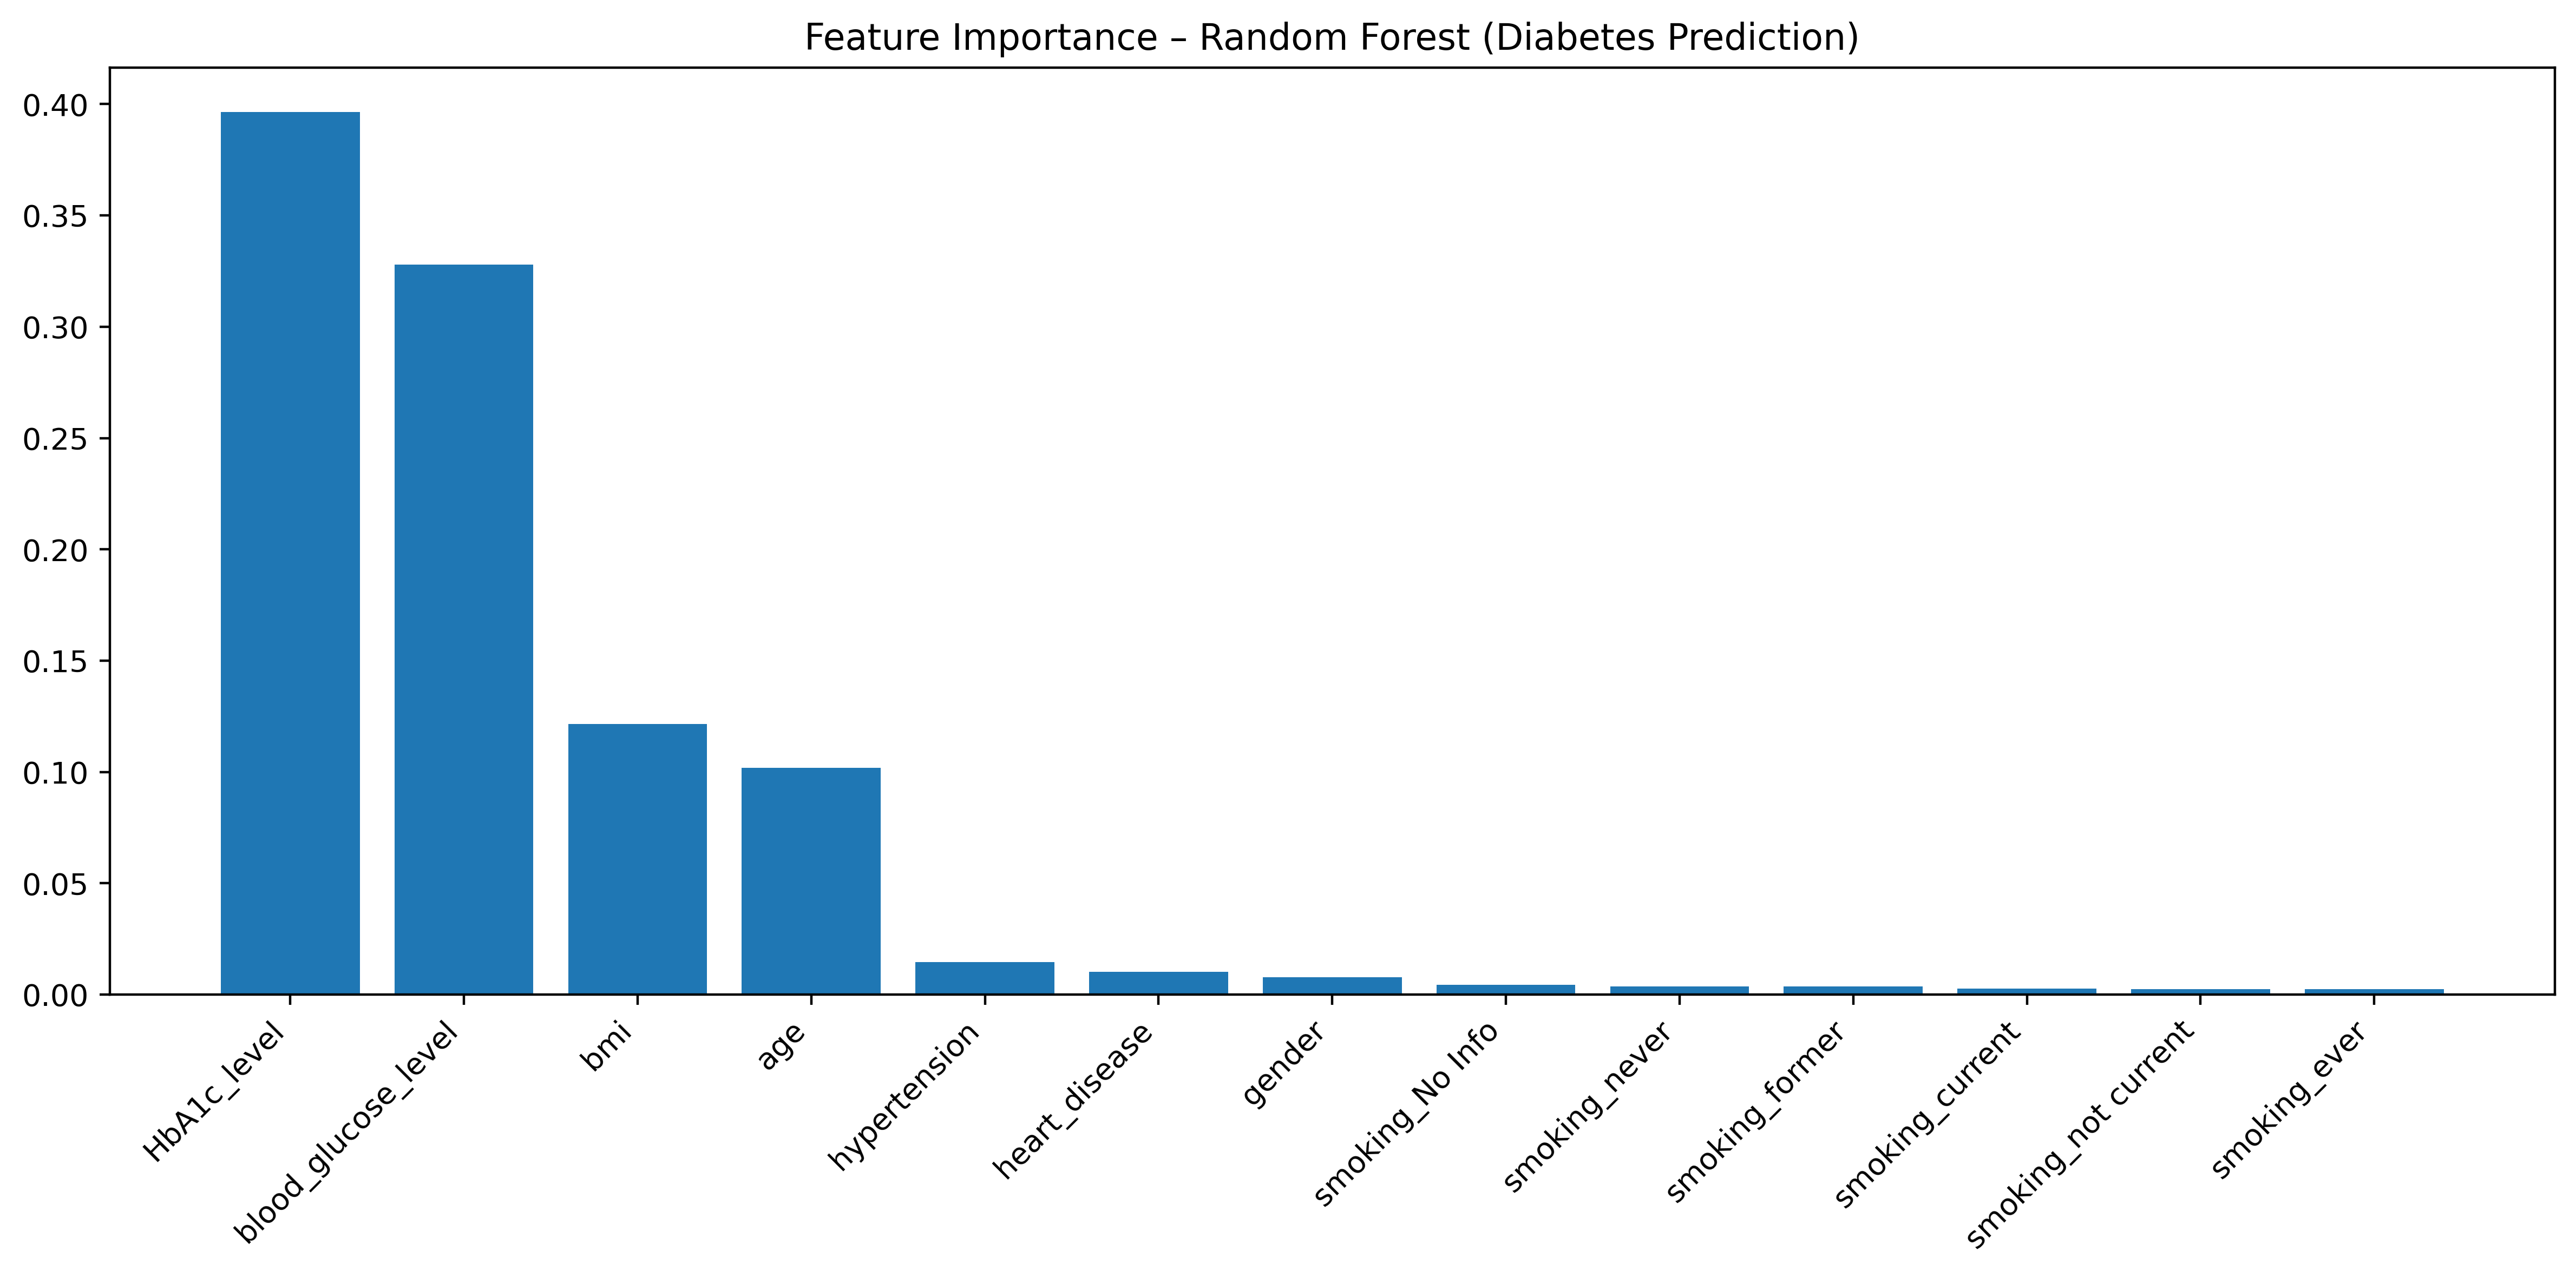

Top 10 đặc trưng quan trọng:
 1. HbA1c_level                    0.3965
 2. blood_glucose_level            0.3279
 3. bmi                            0.1215
 4. age                            0.1020
 5. hypertension                   0.0147
 6. heart_disease                  0.0102
 7. gender                         0.0079
 8. smoking_No Info                0.0044
 9. smoking_never                  0.0037
10. smoking_former                 0.0036


In [15]:
# CELL 5: Nhiệm vụ 3 – Random Forest + Feature Importance
rf = RandomForestClassifier(n_estimators=200, random_state=24, n_jobs=-1)
rf.fit(X_train, y_train)

# Feature importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Feature Importance – Random Forest (Diabetes Prediction)")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# In top 10
print("Top 10 đặc trưng quan trọng:")
for i in range(10):
    print(f"{i+1:2d}. {X.columns[indices[i]]:<30} {importances[indices[i]]:.4f}")